In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
# import multiprocessing as mp
import ot

In [3]:
#check number of cores and compile specter
num_cores = os.cpu_count()
print(f"Number of CPU cores: {num_cores}")

Number of CPU cores: 192


In [4]:
N = 10000
### need access to hadronization points 
points = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/hadronization_points.npy')[N:2*N]
weight = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy')[N:2*N]
#### what is distmatrix and how is this calculated?
distmatrix = np.load('/oscar/data/mleblan6/rjain/trial1/XMD_10k_distmatrix.npy')

In [6]:
points_ttbar = np.load("/oscar/data/mleblan6/lhay/ttbar_100k/hadronization_ttbar_points10k.npy")
weights_ttbar = np.load("/oscar/data/mleblan6/lhay/ttbar_100k/ttbar_weight_10k.npy")[0:N]
distmatrix_ttbar = np.load("/oscar/data/mleblan6/lhay/ttbar_100k/distmatrix_ttbar10k.npy")

In [7]:
hp_xmd_distances = np.load('hp_XMD_jenmethod_constismin.npy')
sho_xmd_distances = np.load('sho_XMD_jenmethod_constismin.npy')
had_xmd_distances = np.load('had_XMD_jenmethod_constismin.npy')
hp_infR_xmd_distances = np.load('hp_infR_XMD_jenmethod_constismin.npy')
sho_infR_xmd_distances = np.load('sho_infR_XMD_jenmethod_constismin.npy')
had_infR_xmd_distances = np.load('had_infR_XMD_jenmethod_constismin.npy')
hp_semd_xmd_distances = np.load('hp_semd_XMD_jenmethod_constismin.npy')
random_xmd_distances = np.load('random_XMD_jenmethod_constismin.npy')
jeppe_xmd_distances = np.load('jeppe_XMD_jenmethod_constismin.npy')
hp_ML_xmd_distances = np.load('hp_ML_XMD_jenmethod_constisminweight.npy')
sho_ML_xmd_distances = np.load('sho_ML_XMD_jenmethod_constisminweight.npy')
had_ML_xmd_distances = np.load('had_ML_XMD_jenmethod_constisminweight.npy')

FileNotFoundError: [Errno 2] No such file or directory: 'hp_XMD_jenmethod_constismin.npy'

In [6]:
hp_radii = [5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 10.5, 11, 11.5, 12, 12.5, 13, 13.5, 14, 14.5, 15, 15.5, 16, 16.5, 17, 17.5, 18, 18.5, 19, 19.5, 
            20, 22.5, 25, 27.5, 30, 150]
sho_radii = [7.5, 8, 8.5, 9, 9.5, 10, 10.5, 11, 11.5, 12, 12.5, 13, 13.5, 14, 14.5, 15, 15.5, 16, 16.5, 17, 17.5, 18, 18.5, 19, 19.5, 20, 
             22.5, 25, 27.5, 30, 150]
had_radii = [10, 10.5, 11, 11.5, 12, 12.5, 13, 13.5, 14, 14.5, 15, 15.5, 16, 16.5, 17, 17.5, 18, 18.5, 19, 19.5, 20, 22.5, 25, 27.5, 30, 150]

path = '/oscar/data/mleblan6/rjain/trial1/'

had_reweights = [ np.load(f'{path}had_reweight_0to10k_10GeV.npy'),
                np.load(f'{path}had_reweight_0to10k_10p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_11GeV.npy'), np.load(f'{path}had_reweight_0to10k_11p5GeV.npy'), 
                np.load(f'{path}had_reweight_0to10k_12GeV.npy'), 
             np.load(f'{path}had_reweight_0to10k_12p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_13GeV.npy'), np.load(f'{path}had_reweight_0to10k_13p5GeV.npy'), 
                np.load(f'{path}had_reweight_0to10k_14GeV.npy'), np.load(f'{path}had_reweight_0to10k_14p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_15GeV.npy'), 
                np.load(f'{path}had_reweight_0to10k_15p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_16GeV.npy'), np.load(f'{path}had_reweight_0to10k_16p5GeV.npy'), 
                np.load(f'{path}had_reweight_0to10k_17GeV.npy'), np.load(f'{path}had_reweight_0to10k_17p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_18GeV.npy'),
             np.load(f'{path}had_reweight_0to10k_18p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_19GeV.npy'), np.load(f'{path}had_reweight_0to10k_19p5GeV.npy'), 
                np.load(f'{path}had_reweight_0to10k_20GeV.npy'), 
             np.load(f'{path}had_reweight_0to10k_22p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_25GeV.npy'), np.load(f'{path}had_reweight_0to10k_27p5GeV.npy'), 
             np.load(f'{path}had_reweight_0to10k_30GeV.npy'), np.load(f'{path}had_reweight_0to10k_150GeV.npy')]
sho_reweights = [np.load(f'{path}sho_reweight_0to10k_7p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_8GeV.npy'), np.load(f'{path}sho_reweight_0to10k_8p5GeV.npy'), 
                np.load(f'{path}sho_reweight_0to10k_9GeV.npy'), np.load(f'{path}sho_reweight_0to10k_9p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_10GeV.npy'),
                np.load(f'{path}sho_reweight_0to10k_10p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_11GeV.npy'), np.load(f'{path}sho_reweight_0to10k_11p5GeV.npy'), 
                np.load(f'{path}sho_reweight_0to10k_12GeV.npy'),
             np.load(f'{path}sho_reweight_0to10k_12p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_13GeV.npy'), np.load(f'{path}sho_reweight_0to10k_13p5GeV.npy'), 
                np.load(f'{path}sho_reweight_0to10k_14GeV.npy'), np.load(f'{path}sho_reweight_0to10k_14p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_15GeV.npy'), 
                np.load(f'{path}sho_reweight_0to10k_15p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_16GeV.npy'), np.load(f'{path}sho_reweight_0to10k_16p5GeV.npy'), 
                np.load(f'{path}sho_reweight_0to10k_17GeV.npy'), np.load(f'{path}sho_reweight_0to10k_17p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_18GeV.npy'),
             np.load(f'{path}sho_reweight_0to10k_18p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_19GeV.npy'), np.load(f'{path}sho_reweight_0to10k_19p5GeV.npy'), 
                np.load(f'{path}sho_reweight_0to10k_20GeV.npy'), 
             np.load(f'{path}sho_reweight_0to10k_22p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_25GeV.npy'), np.load(f'{path}sho_reweight_0to10k_27p5GeV.npy'), 
             np.load(f'{path}sho_reweight_0to10k_30GeV.npy'), np.load(f'{path}sho_reweight_0to10k_150GeV.npy')]

hp_reweights = [np.load(f'{path}hp_reweight_0to10k_5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_5p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_6GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_6p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_7GeV.npy'), np.load(f'{path}hp_reweight_0to10k_7p5GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_8GeV.npy'), np.load(f'{path}hp_reweight_0to10k_8p5GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_9GeV.npy'), np.load(f'{path}hp_reweight_0to10k_9p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_10GeV.npy'),
                np.load(f'{path}hp_reweight_0to10k_10p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_11GeV.npy'), np.load(f'{path}hp_reweight_0to10k_11p5GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_12GeV.npy'),
             np.load(f'{path}hp_reweight_0to10k_12p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_13GeV.npy'), np.load(f'{path}hp_reweight_0to10k_13p5GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_14GeV.npy'), np.load(f'{path}hp_reweight_0to10k_14p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_15GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_15p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_16GeV.npy'), np.load(f'{path}hp_reweight_0to10k_16p5GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_17GeV.npy'), np.load(f'{path}hp_reweight_0to10k_17p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_18GeV.npy'),
             np.load(f'{path}hp_reweight_0to10k_18p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_19GeV.npy'), np.load(f'{path}hp_reweight_0to10k_19p5GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_20GeV.npy'), 
             np.load(f'{path}hp_reweight_0to10k_22p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_25GeV.npy'), np.load(f'{path}hp_reweight_0to10k_27p5GeV.npy'), 
             np.load(f'{path}hp_reweight_0to10k_30GeV.npy'), np.load(f'{path}hp_reweight_0to10k_150GeV.npy')]

In [7]:
hp_semd_reweights = np.load('/oscar/data/mleblan6/rjain/trial1/semd_reweights.npy')
hp_infR_reweights = np.load('/oscar/data/mleblan6/rjain/trial1/infR_reweights_had.npy')
sho_infR_reweights = np.load('/oscar/data/mleblan6/rjain/trial1/infR_reweights_sho.npy')
had_infR_reweights = np.load('/oscar/data/mleblan6/rjain/trial1/infR_reweights_had.npy')
jeppe_reweights = np.load('/oscar/data/mleblan6/rjain/trial1/jeppe_reweights.npy')
rand_reweight = np.zeros((25,10000))
def create_mixed_array(N, M):
    arr_pos = np.random.rand(N)        # N numbers in [0, 1]
    arr_neg = -np.random.rand(M)       # M numbers in [-1, 0]
    arr = np.concatenate([arr_pos, arr_neg])
    np.random.shuffle(arr)             # shuffle in-place
    return arr

random_distances = []
neg_num = np.linspace(len(weight[weight<0]),0,25, dtype = 'int')
for i in range(25):
    rand_reweight[i] = create_mixed_array(10000-neg_num[i], neg_num[i])

rand_reweight = np.array(rand_reweight)
hp_ML_reweights = np.load('/oscar/data/mleblan6/rjain/trial1/ML_hp_reweights.npy')
had_ML_reweights = np.load('/oscar/data/mleblan6/rjain/trial1/ML_had_reweights.npy')
sho_ML_reweights = np.load('/oscar/data/mleblan6/rjain/trial1/ML_sho_reweights.npy')

In [8]:
hp_ttbar_radii = [5, 15, 18, 19, 20, 25, 30, 100]
hp_ttbar_reweights = [ np.load(f"/users/lhay/cres-distance/reweighted_files/10k_ttbar_hp/10k_hp_emd_reweight_{R}gev_ttbar.npy")/(1.455 * 10**4) for R in hp_ttbar_radii]
print(hp_ttbar_reweights)
print(np.sum(weights_ttbar))
print(np.sum(hp_ttbar_reweights[0]))

[array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.00416388, 0.01249164, 0.00416388, ..., 0.00178452, 0.01249164,
       0.01249164]), array([3.3281165e-05, 1.2491640e-02, 4.1638800e-03, ..., 1.1896800e-04,
       1.2491640e-02, 5.9484000e-04])]
68.17937112
68.17937112000001


In [9]:
ps_ttbar_radii = [1, 15, 18, 24, 24, 30, 50, 100]
ps_ttbar_reweights = [ np.load(f"/users/lhay/cres-distance/reweighted_files/10k_ttbar_ps/10k_ps_emd_reweight_{R}gev_ttbar.npy")/(1.455 * 10**4) for R in ps_ttbar_radii]
print(ps_ttbar_reweights)
print(np.sum(weights_ttbar))
print(np.sum(ps_ttbar_reweights[0]))

[array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([1.41123072e-05, 1.24916400e-02, 1.24916400e-02, ...,
       1.24916400e-02, 1.24916400e-02, 1.24916400e-02]), array([1.41123072e-05, 1.24916400e-02, 1.24916400e-02, ...,
       1.24916400e-02, 1.24916400e-02, 1.24916400e-02])]
68.17937112
68.17937112000001


In [10]:
had_ttbar_radii = [1, 21, 25, 28, 30, 50, 100]
had_ttbar_reweights = [ np.load(f"/users/lhay/cres-distance/reweighted_files/10k_ttbar_had/10k_had_emd_reweight_{R}gev_ttbar.npy")/(1.455 * 10**4) for R in had_ttbar_radii]
print(had_ttbar_reweights)
print(np.sum(weights_ttbar))
print(np.sum(had_ttbar_reweights[0]))

[array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([0.01249164, 0.01249164, 0.01249164, ..., 0.01249164, 0.01249164,
       0.01249164]), array([8.62563943e-06, 1.24916400e-02, 1.24916400e-02, ...,
       1.24916400e-02, 1.24916400e-02, 1.24916400e-02]), array([8.62563943e-06, 1.24916400e-02, 1.24916400e-02, ...,
       1.24916400e-02, 1.13560364e-03, 1.24916400e-02])]
68.17937112
68.17937112000001


In [11]:
hp_ttbar_xmd_distances = np.load('hp_ttbar_XMD_constis1.npy')
sho_ttbar_xmd_distances = np.load('ps_ttbar_XMD_constis1.npy')
had_ttbar_xmd_distances = np.load('had_ttbar_XMD_constis1.npy')

In [12]:
had_ttbar_temp = []
for i in range(len(had_ttbar_reweights)):
    num_negs = len(np.where(weights_ttbar < 0)[0])
    had_ttbar_temp.append(1 - len(np.where(had_ttbar_reweights[i] < 0)[0]) / num_negs)

sho_ttbar_temp = []
for i in range(len(ps_ttbar_reweights)):
    num_negs = len(np.where(weights_ttbar < 0)[0])
    sho_ttbar_temp.append(1 - len(np.where(ps_ttbar_reweights[i] < 0)[0]) / num_negs)

hp_ttbar_temp = []
for i in range(len(hp_ttbar_reweights)):
    num_negs = len(np.where(weights_ttbar < 0)[0])
    hp_ttbar_temp.append(1 - len(np.where(hp_ttbar_reweights[i] < 0)[0]) / num_negs)


Text(0.5, 1.0, '10k TTbar')

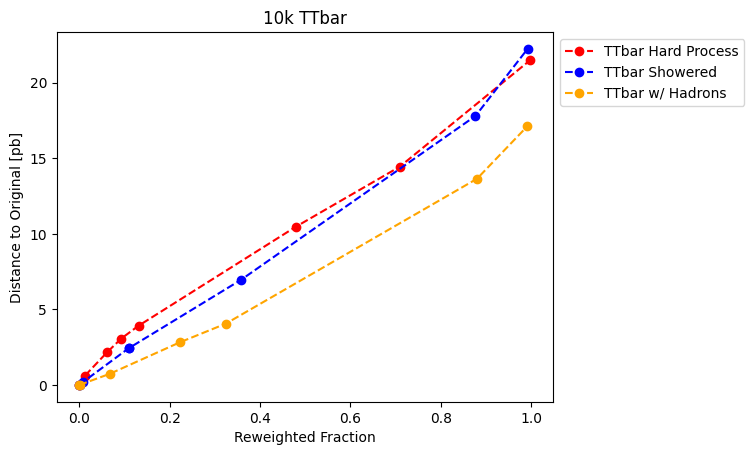

In [13]:
# plt.plot([0], [0], marker = 'o', color = 'magenta')
# plt.axvline(x=0.1, color = 'black')
# plt.axvline(x=0.3, color = 'black')
# plt.axvline(x=0.5, color = 'black')
# plt.axvline(x=0.7, color = 'black')
# plt.axvline(x=0.9, color = 'black')
const = 1
# plt.axhline(13, color = 'black', label = 'XS Error (1% of total XS)')


plt.plot(hp_ttbar_temp, hp_ttbar_xmd_distances*(1482/68)*37/22, marker = 'o', color = 'red', linestyle = '--', label = 'TTbar Hard Process');
plt.plot(sho_ttbar_temp, sho_ttbar_xmd_distances*(1482/68)*37/22, marker = 'o', color = 'blue', linestyle = '--', label = 'TTbar Showered');
plt.plot(had_ttbar_temp, had_ttbar_xmd_distances*(1482/68)*37/22, marker = 'o', color = 'orange', linestyle = '--', label = 'TTbar w/ Hadrons');


#plt.axvline(x=0, color = 'magenta')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Reweighted Fraction')
plt.ylabel('Distance to Original [pb]')
plt.title(f'10k TTbar')
#plt.xlim(-0.01,1.01)

#plt.yscale('log')

In [14]:
had_temp = []
for i in range(len(had_reweights)):
    num_negs = len(np.where(weight < 0)[0])
    had_temp.append(1 - len(np.where(had_reweights[i] < 0)[0]) / num_negs)

sho_temp = []
for i in range(len(sho_reweights)):
    num_negs = len(np.where(weight < 0)[0])
    sho_temp.append(1 - len(np.where(sho_reweights[i] < 0)[0]) / num_negs)

hp_temp = []
for i in range(len(hp_reweights)):
    num_negs = len(np.where(weight < 0)[0])
    hp_temp.append(1 - len(np.where(hp_reweights[i] < 0)[0]) / num_negs)

semd_temp = []
for i in range(50):
    num_negs = len(np.where(weight < 0)[0])
    semd_temp.append(1 - len(np.where(hp_semd_reweights[i] < 0)[0]) / num_negs)

hp_infR_temp = []
sho_infR_temp = []
had_infR_temp = []
for i in range(20):
    num_negs = len(np.where(weight<0)[0])
    hp_infR_temp.append(1 - len(np.where(hp_infR_reweights[i] < 0)[0]) / num_negs)
    sho_infR_temp.append(1 - len(np.where(sho_infR_reweights[i] < 0)[0]) / num_negs)
    had_infR_temp.append(1 - len(np.where(had_infR_reweights[i] < 0)[0]) / num_negs)

random_temp = []
for i in range(25):
    num_negs = len(np.where(weight<0)[0])
    random_temp.append(1-len(np.where(rand_reweight[i] < 0)[0]) / num_negs)

jeppe_temp = []
for i in range(50):
    num_negs = len(np.where(weight<0)[0])
    jeppe_temp.append(1-len(np.where(jeppe_reweights[i] < 0)[0]) / num_negs)


hp_ML_temp = []
for i in range(50):
    num_negs = len(np.where(weight<0)[0])
    hp_ML_temp.append(1-len(np.where(hp_ML_reweights[i] < 0)[0]) / num_negs)


sho_ML_temp = []
for i in range(50):
    num_negs = len(np.where(weight<0)[0])
    sho_ML_temp.append(1-len(np.where(sho_ML_reweights[i] < 0)[0]) / num_negs)


had_ML_temp = []
for i in range(50):
    num_negs = len(np.where(weight<0)[0])
    had_ML_temp.append(1-len(np.where(had_ML_reweights[i] < 0)[0]) / num_negs)

Text(0.5, 0, 'Max Cell Radius [GeV]')

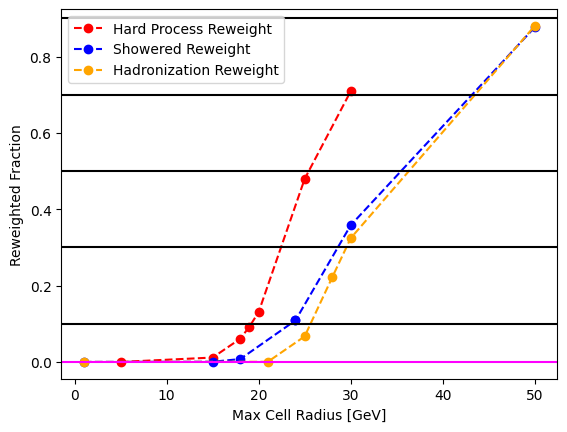

In [15]:
plt.plot(hp_ttbar_radii[:-1], hp_ttbar_temp[:-1], marker = 'o', color = 'red', linestyle = '--', label = 'Hard Process Reweight');
plt.plot(ps_ttbar_radii[:-1], sho_ttbar_temp[:-1], marker = 'o', color = 'blue', linestyle = '--', label = 'Showered Reweight');
plt.plot(had_ttbar_radii[:-1], had_ttbar_temp[:-1], marker = 'o', color = 'orange', linestyle = '--', label = 'Hadronization Reweight');
#plt.plot(hp_semd_radii, semd_temp, marker = '^', color = 'purple', linestyle = '--', label = 'Hard Process SEMD Reweight');
plt.axhline(y=0.1, color = 'black')
plt.axhline(y=0.3, color = 'black')
plt.axhline(y=0.5, color = 'black')
plt.axhline(y=0.7, color = 'black')
plt.axhline(y=0.9, color = 'black')
plt.axhline(y=0, color = 'magenta')
plt.legend()
plt.ylabel('Reweighted Fraction')
plt.xlabel('Max Cell Radius [GeV]')

1482.89071392
2.1503488089144978
14.869118731023528


(0.0, 45.0)

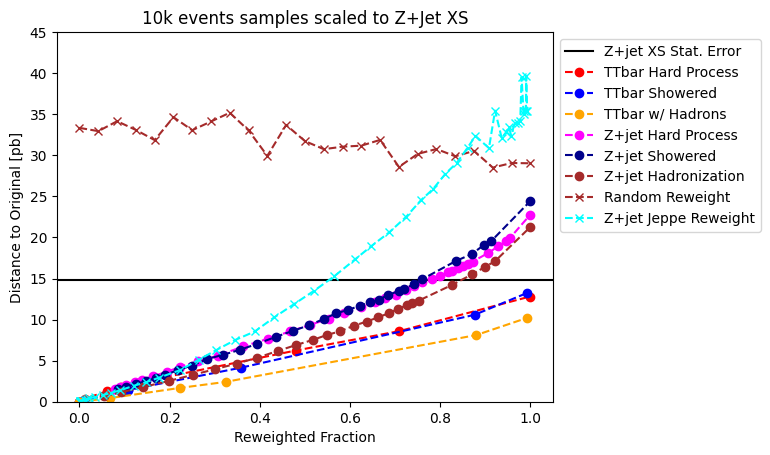

In [22]:
# plt.plot([0], [0], marker = 'o', color = 'magenta')
# plt.axvline(x=0.1, color = 'black')
# plt.axvline(x=0.3, color = 'black')
# plt.axvline(x=0.5, color = 'black')
# plt.axvline(x=0.7, color = 'black')
# plt.axvline(x=0.9, color = 'black')
const = -min(weight)
plt.axhline(np.sum(weight)/np.sqrt(len(weight)), color = 'black', label = 'Z+jet XS Stat. Error')
print(np.sum(weight))
print(680/np.sqrt(1e5))
print(np.sum(weights_ttbar)/np.sqrt(len(weights_ttbar))*(1483/68))
plt.plot(hp_ttbar_temp, hp_ttbar_xmd_distances*(1483/68), marker = 'o', color = 'red', linestyle = '--', label = 'TTbar Hard Process');
plt.plot(sho_ttbar_temp, sho_ttbar_xmd_distances*(1483/68), marker = 'o', color = 'blue', linestyle = '--', label = 'TTbar Showered');
plt.plot(had_ttbar_temp, had_ttbar_xmd_distances*(1483/68), marker = 'o', color = 'orange', linestyle = '--', label = 'TTbar w/ Hadrons');
plt.plot(hp_temp, hp_xmd_distances, marker = 'o', color = 'magenta', linestyle = '--', label = 'Z+jet Hard Process');
plt.plot(sho_temp, sho_xmd_distances, marker = 'o', color = 'darkblue', linestyle = '--', label = 'Z+jet Showered');
plt.plot(had_temp, had_xmd_distances, marker = 'o', color = 'brown', linestyle = '--', label = 'Z+jet Hadronization');
# plt.plot(semd_temp, hp_semd_xmd_distances, marker = '^', color = 'purple', linestyle = '--', label = 'SEMD Reweight');
# plt.plot(hp_infR_temp, hp_infR_xmd_distances, marker = 's', color = 'pink', linestyle = '--', label = 'Hard Process inf R Reweight');
# plt.plot(sho_infR_temp, sho_infR_xmd_distances, marker = 's', color = 'green', linestyle = '--', label = 'Showered inf R Reweight');
# plt.plot(had_infR_temp, had_infR_xmd_distances, marker = 's', color = 'magenta', linestyle = '--', label = 'Hadronization inf R Reweight');
plt.plot(random_temp, random_xmd_distances, marker = 'x', color = 'brown', linestyle = '--', label = 'Random Reweight');
plt.plot(jeppe_temp, jeppe_xmd_distances, marker = 'x', color = 'cyan', linestyle = '--', label = 'Z+jet Jeppe Reweight');
# plt.plot(hp_ML_temp, hp_ML_xmd_distances, marker = 'v', color = 'mediumpurple', linestyle = '--', label = 'ML Hard Process Reweight');
# plt.plot(sho_ML_temp, sho_ML_xmd_distances, marker = 'v', color = 'lime', linestyle = '--', label = 'ML Showered Reweight');
# plt.plot(had_ML_temp, had_ML_xmd_distances, marker = 'v', color = 'slategray', linestyle = '--', label = 'ML Hadronization Reweight');


#plt.axvline(x=0, color = 'magenta')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Reweighted Fraction')
plt.ylabel('Distance to Original [pb]')
plt.title(f'10k events samples scaled to Z+Jet XS')
#plt.xlim(-0.01,1.01)
plt.ylim(0,45)
#plt.yscale('log')

1482.89071392
2.1503488089144978
14.859092352917646
0.3746 0.2271


(0.0, 45.0)

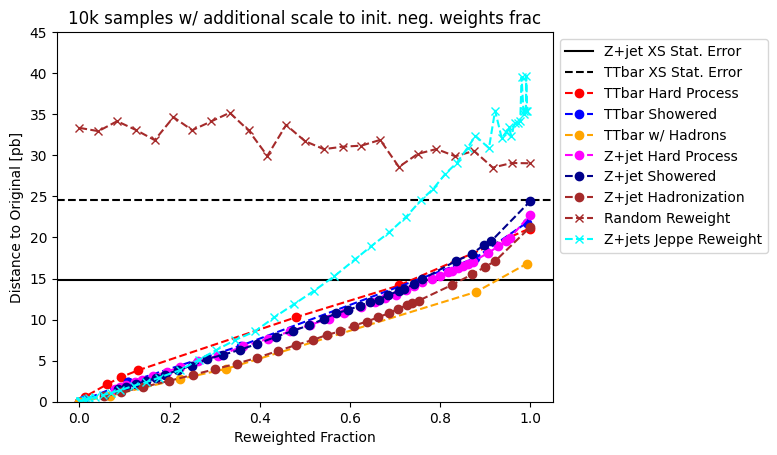

In [23]:
# plt.plot([0], [0], marker = 'o', color = 'magenta')
# plt.axvline(x=0.1, color = 'black')
# plt.axvline(x=0.3, color = 'black')
# plt.axvline(x=0.5, color = 'black')
# plt.axvline(x=0.7, color = 'black')
# plt.axvline(x=0.9, color = 'black')
frac_neg = len(np.where(weight<0)[0])/len(weight)
frac_neg_ttbar = len(np.where(weights_ttbar < 0)[0])/len(weights_ttbar)
sf = frac_neg/frac_neg_ttbar
const = -min(weight)
plt.axhline(np.sum(weight)/np.sqrt(len(weight)), color = 'black', label = 'Z+jet XS Stat. Error')
print(np.sum(weight))
print(680/np.sqrt(1e5))
plt.axhline(np.sum(weights_ttbar)/np.sqrt(len(weights_ttbar))*(1482/68)*sf, color = 'black', linestyle = '--', label = 'TTbar XS Stat. Error')
print(np.sum(weights_ttbar)/np.sqrt(len(weights_ttbar))*(1482/68))
frac_neg = len(np.where(weight<0)[0])/len(weight)
frac_neg_ttbar = len(np.where(weights_ttbar < 0)[0])/len(weights_ttbar)
print(frac_neg, frac_neg_ttbar)
plt.plot(hp_ttbar_temp, hp_ttbar_xmd_distances*(1482/68)*sf, marker = 'o', color = 'red', linestyle = '--', label = 'TTbar Hard Process');
plt.plot(sho_ttbar_temp, sho_ttbar_xmd_distances*(1482/68)*sf, marker = 'o', color = 'blue', linestyle = '--', label = 'TTbar Showered');
plt.plot(had_ttbar_temp, had_ttbar_xmd_distances*(1482/68)*sf, marker = 'o', color = 'orange', linestyle = '--', label = 'TTbar w/ Hadrons');
plt.plot(hp_temp, hp_xmd_distances, marker = 'o', color = 'magenta', linestyle = '--', label = 'Z+jet Hard Process');
plt.plot(sho_temp, sho_xmd_distances, marker = 'o', color = 'darkblue', linestyle = '--', label = 'Z+jet Showered');
plt.plot(had_temp, had_xmd_distances, marker = 'o', color = 'brown', linestyle = '--', label = 'Z+jet Hadronization');
# plt.plot(semd_temp, hp_semd_xmd_distances, marker = '^', color = 'purple', linestyle = '--', label = 'SEMD Reweight');
# plt.plot(hp_infR_temp, hp_infR_xmd_distances, marker = 's', color = 'pink', linestyle = '--', label = 'Hard Process inf R Reweight');
# plt.plot(sho_infR_temp, sho_infR_xmd_distances, marker = 's', color = 'green', linestyle = '--', label = 'Showered inf R Reweight');
# plt.plot(had_infR_temp, had_infR_xmd_distances, marker = 's', color = 'magenta', linestyle = '--', label = 'Hadronization inf R Reweight');
plt.plot(random_temp, random_xmd_distances, marker = 'x', color = 'brown', linestyle = '--', label = 'Random Reweight');
plt.plot(jeppe_temp, jeppe_xmd_distances, marker = 'x', color = 'cyan', linestyle = '--', label = 'Z+jets Jeppe Reweight');
# plt.plot(hp_ML_temp, hp_ML_xmd_distances, marker = 'v', color = 'mediumpurple', linestyle = '--', label = 'ML Hard Process Reweight');
# plt.plot(sho_ML_temp, sho_ML_xmd_distances, marker = 'v', color = 'lime', linestyle = '--', label = 'ML Showered Reweight');
# plt.plot(had_ML_temp, had_ML_xmd_distances, marker = 'v', color = 'slategray', linestyle = '--', label = 'ML Hadronization Reweight');


#plt.axvline(x=0, color = 'magenta')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Reweighted Fraction')
plt.ylabel('Distance to Original [pb]')
plt.title(f'10k samples w/ additional scale to init. neg. weights frac')
#plt.xlim(-0.01,1.01)
plt.ylim(0,45)
#plt.yscale('log')

(0.0, 25.0)

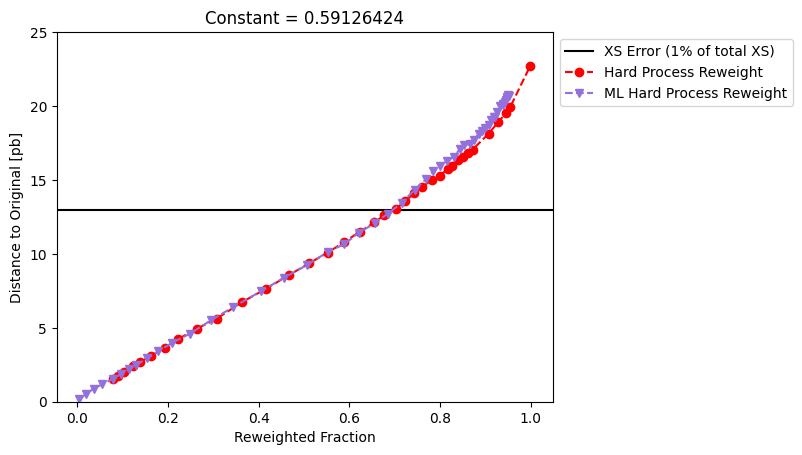

In [18]:
# plt.plot([0], [0], marker = 'o', color = 'magenta')
# plt.axvline(x=0.1, color = 'black')
# plt.axvline(x=0.3, color = 'black')
# plt.axvline(x=0.5, color = 'black')
# plt.axvline(x=0.7, color = 'black')
# plt.axvline(x=0.9, color = 'black')
plt.axhline(13, color = 'black', label = 'XS Error (1% of total XS)')


plt.plot(hp_temp, hp_xmd_distances, marker = 'o', color = 'red', linestyle = '--', label = 'Hard Process Reweight');
plt.plot(hp_ML_temp, hp_ML_xmd_distances, marker = 'v', color = 'mediumpurple', linestyle = '--', label = 'ML Hard Process Reweight');



#plt.axvline(x=0, color = 'magenta')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Reweighted Fraction')
plt.ylabel('Distance to Original [pb]')
plt.title(f'Constant = {const}')
# plt.xlim(.23,.27)
plt.ylim(0,25)
#plt.yscale('log')

(0.0, 25.0)

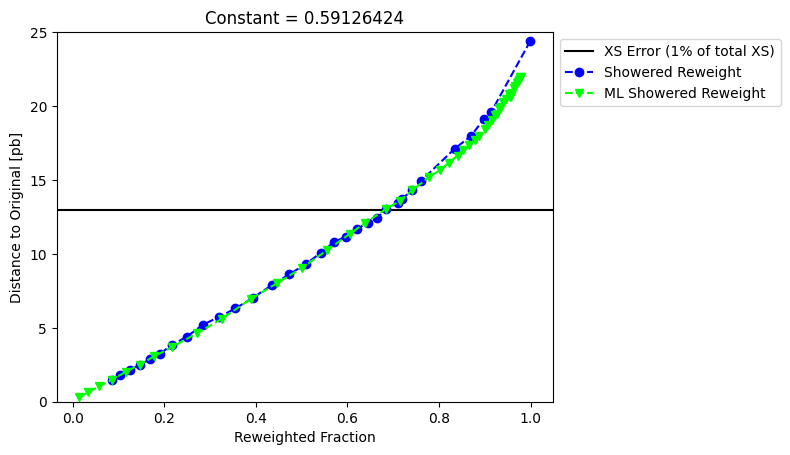

In [19]:
# plt.plot([0], [0], marker = 'o', color = 'magenta')
# plt.axvline(x=0.1, color = 'black')
# plt.axvline(x=0.3, color = 'black')
# plt.axvline(x=0.5, color = 'black')
# plt.axvline(x=0.7, color = 'black')
# plt.axvline(x=0.9, color = 'black')
plt.axhline(13, color = 'black', label = 'XS Error (1% of total XS)')


plt.plot(sho_temp, sho_xmd_distances, marker = 'o', color = 'blue', linestyle = '--', label = 'Showered Reweight');
plt.plot(sho_ML_temp, sho_ML_xmd_distances, marker = 'v', color = 'lime', linestyle = '--', label = 'ML Showered Reweight');



#plt.axvline(x=0, color = 'magenta')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Reweighted Fraction')
plt.ylabel('Distance to Original [pb]')
plt.title(f'Constant = {const}')
# plt.xlim(.23,.27)
plt.ylim(0,25)
#plt.yscale('log')

Text(0.5, 1.0, 'Constant = 0.59126424')

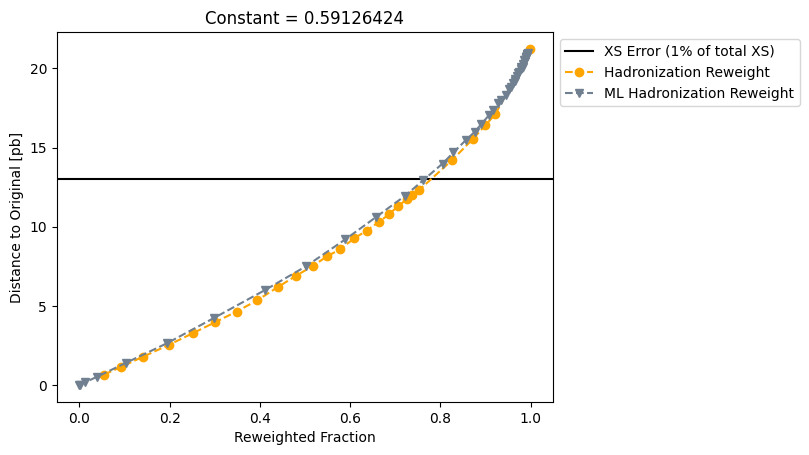

In [20]:
# plt.plot([0], [0], marker = 'o', color = 'magenta')
# plt.axvline(x=0.1, color = 'black')
# plt.axvline(x=0.3, color = 'black')
# plt.axvline(x=0.5, color = 'black')
# plt.axvline(x=0.7, color = 'black')
# plt.axvline(x=0.9, color = 'black')
plt.axhline(13, color = 'black', label = 'XS Error (1% of total XS)')

plt.plot(had_temp, had_xmd_distances, marker = 'o', color = 'orange', linestyle = '--', label = 'Hadronization Reweight');
plt.plot(had_ML_temp, had_ML_xmd_distances, marker = 'v', color = 'slategray', linestyle = '--', label = 'ML Hadronization Reweight');


#plt.axvline(x=0, color = 'magenta')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Reweighted Fraction')
plt.ylabel('Distance to Original [pb]')
plt.title(f'Constant = {const}')
#plt.xlim(-0.01,1.01)
# plt.ylim(0,25)
#plt.yscale('log')